<a href="https://colab.research.google.com/github/zynoozyno6-rgb/DL-assaingment-1/blob/main/DL_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Breast Cancer Classification Using MLP Nreural Network

اولا: استيراد المكتبات والوحدات اللازمة

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


تحميل بيانات جاهزة موجودة داخل مكتبة sklearn ,ومعرفة عدد featuers=30,و حجم العينات جيد للتدريب 569

In [5]:
# تحميل بيانات سرطان الثدي
data = load_breast_cancer()

X = data.data
y = data.target

print("عدد العينات:", X.shape[0])
print("عدد الخصائص:", X.shape[1])

عدد العينات: 569
عدد الخصائص: 30


تقسيم البيانات الى بيانات تدريب واختبار وتحديد كم نسبة بيانات الاختبارات من نسبة البيانات الكلية

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

نقوم بعمل توحيد للبيانات للبيانات التدريب فقط لتجنب مشكلة تسرب البيانات

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

انشاء الشبكة العصبية بطبقات مخفية عديدة لنتمكن من فصل البيانات بطريقة جيدة

In [8]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(30,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


تهيئة او النموذج للتدريب نحدد خوارزمية التحسين ودوالة حساب الخسارة ومقياس الدقة

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

تدريب النموذج وتحديد 50 عملية لمرور النموذج على البيانات وهذا التكرار يفيد في تعلم الشبكة وزيادة دقتها وتحديد قيمة لضبط المعلمات الفائقة

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7500 - loss: 0.5594 - val_accuracy: 0.8571 - val_loss: 0.4271
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8709 - loss: 0.3870 - val_accuracy: 0.9011 - val_loss: 0.3188
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9121 - loss: 0.2891 - val_accuracy: 0.9121 - val_loss: 0.2547
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9286 - loss: 0.2282 - val_accuracy: 0.9121 - val_loss: 0.2148
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9396 - loss: 0.1879 - val_accuracy: 0.9231 - val_loss: 0.1868
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9505 - loss: 0.1595 - val_accuracy: 0.9231 - val_loss: 0.1661
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9533 - loss: 0.1380 - val_accuracy: 0.9451 - val_loss: 0.1501
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9643 - loss: 0.1211 - val_accuracy: 0.9560 - val_lo

تقييم النموذج من خلال عرض نسبة الخطا ,وحساب الدقة

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9737 - loss: 0.0691
Test Loss: 0.06907115131616592
Test Accuracy: 0.9736841917037964


التنبؤ بقيمة جديدة وحددنا لها حد عتبة فوق 0.5class1 else class2

In [12]:
prediction = model.predict(X_test[:5])

print(prediction)
print((prediction > 0.5).astype(int))
print(y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[9.3806434e-01]
 [2.1398311e-07]
 [3.3855606e-05]
 [9.9966127e-01]
 [9.9996239e-01]]
[[1]
 [0]
 [0]
 [1]
 [1]]
[1 0 0 1 1]


عرض مخطط للشبكة

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,613 (18.02 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,076 (12.02 KB)

رسم منحنى قيمة الخسارة

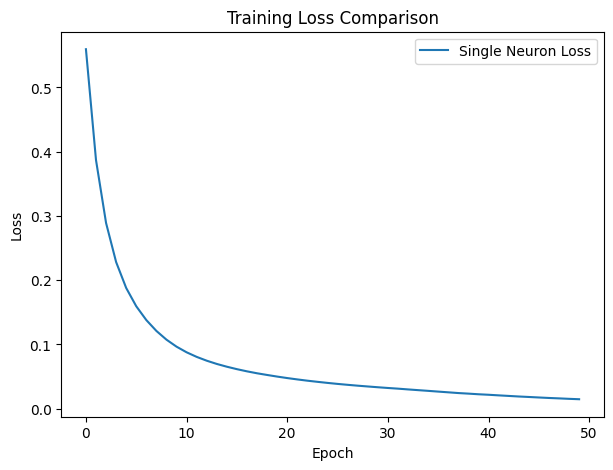

In [15]:
plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Single Neuron Loss")


plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

بوساتي لاإلك ي دكتورتي إلاء ❤️🕊️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️